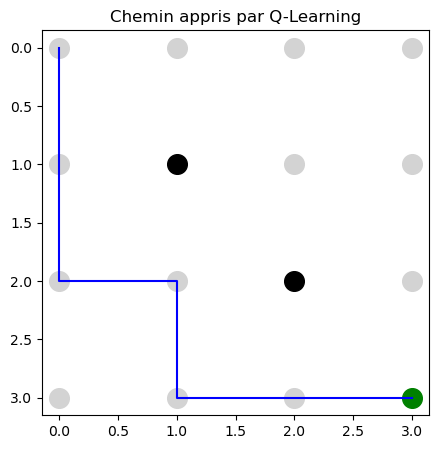

Training terminé 


In [3]:
import random
import matplotlib.pyplot as plt

#  ENVIRONNEMENT
# on définit la grille :
# S = start (départ)
# G = goal (objectif)
# X = obstacle
# . = case normale
grid = [
    ["S", ".", ".", "."],
    [".", "X", ".", "."],
    [".", ".", "X", "."],
    [".", ".", ".", "G"]
]
# nombre de lignes de la grille
n_rows = len(grid)
# nombre de colonnes de la grille
n_cols = len(grid[0])

# actions possibles :
# 0 = haut, 1 = bas, 2 = gauche, 3 = droite
actions = [0, 1, 2, 3] 

#  INITIALISATION Q-TABLE
# dictionnaire qui va contenir les valeurs Q
Q = {}

for i in range(n_rows):
    for j in range(n_cols):
        Q[(i, j)] = [0, 0, 0, 0]
        # pour chaque case on initialise les 4 actions à 0


#  FONCTIONS DE BASE
def get_reward(i, j):
    # pour chaque case on initialise les 4 actions à 0
    if grid[i][j] == "G":
        return 10
        # si on arrive au but → récompense positive
    if grid[i][j] == "X":
        return -10
        # si obstacle →  pénalité
        
    # sinon chaque déplacement coûte -1    
    return -1


def move(i, j, action):
    # cette fonction déplace l’agent selon l’action choisie
    if action == 0: i -= 1
    if action == 1: i += 1
    if action == 2: j -= 1
    if action == 3: j += 1

    # éviter sortir de la grille
    i = max(0, min(i, n_rows - 1))
    j = max(0, min(j, n_cols - 1))
    # on retourne la nouvelle position
    return i, j

# Q-LEARNING ALGO
alpha = 0.1   # learning rate
gamma = 0.9   # futur importance
epsilon = 0.2 # exploration
episodes = 200 # nombre de fois où l’agent va apprendre

for ep in range(episodes):
    # on remet l’agent au départ à chaque épisode
    i, j = 0, 0
    # tant qu’on n’a pas atteint le but
    while grid[i][j] != "G":

        # exploration ou exploitation
        if random.random() < epsilon:
            # exploration : action aléatoire
            action = random.choice(actions)
        else:
            # exploitation : meilleure action connue
            action = Q[(i, j)].index(max(Q[(i, j)]))

        # action
        ni, nj = move(i, j, action)
        # on récupère la récompense
        reward = get_reward(ni, nj)

        # Q-learning update
        Q[(i, j)][action] += alpha * (
            reward + gamma * max(Q[(ni, nj)]) - Q[(i, j)][action]
        )
         # on met à jour la position
        i, j = ni, nj

        if grid[i][j] == "G":
            break
            # si on atteint le but on arrête

#  reconstruire le chemin
i, j = 0, 0
# on repart du début
path = [(i, j)]
# on stocke le chemin
visited = set()
# pour éviter les boucles infinies

while grid[i][j] != "G":
     # on marque la case comme visitée
    visited.add((i, j))
    # choisir meilleure action apprise
    action = Q[(i, j)].index(max(Q[(i, j)]))

    # on se deplace
    if action == 0: i -= 1
    if action == 1: i += 1
    if action == 2: j -= 1
    if action == 3: j += 1

    # rester dans la grille
    i = max(0, min(i, len(grid)-1))
    j = max(0, min(j, len(grid[0])-1))

    if (i, j) in visited:
        break  # éviter boucle infinie
    # on ajoute la position au chemin
    path.append((i, j))

# afficher la grille
plt.figure(figsize=(5,5))

for i in range(len(grid)):
    for j in range(len(grid[0])):

        if grid[i][j] == "X":
            plt.scatter(j, i, color="black", s=200)

        elif grid[i][j] == "G":
            plt.scatter(j, i, color="green", s=200)

        else:
            plt.scatter(j, i, color="lightgray", s=200)

# afficher le chemin
px = [p[1] for p in path]
py = [p[0] for p in path]
plt.plot(px, py, color="blue")
plt.gca().invert_yaxis()
plt.title("Chemin appris par Q-Learning")
plt.show()

print("Training terminé ")